## Imports

In [20]:
import sys
import os

# Add the parent directory (which contains models.py) to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
from models import SimpleLinearRegression, MultiLinearRegression

## Data setup and general insight

In [4]:
df = pd.read_csv("./gd_univariate.csv")

In [14]:
df[(df["X"] > 0.9) & (df["X"] < 1.1)]

,X,y
17,1.049513,5.509464
24,0.912140,4.484805
27,1.028469,5.198502
41,0.990354,4.881899
47,1.040136,4.939551
48,1.093421,6.120401
65,1.085392,6.452444
89,0.944430,5.511895
95,0.987591,5.048664
96,1.045466,5.620579


In [10]:
df.describe()

,X,y
count,100.000000,100.000000
mean,0.940361,5.290725
std,0.594979,2.063984
min,0.011044,1.856879
25%,0.386402,3.536836
50%,0.928285,5.050472
75%,1.460406,7.149545
max,1.973774,9.299120


In [8]:
X = df["X"].to_numpy(dtype=np.float64)
y = df["y"].to_numpy(dtype=np.float64)

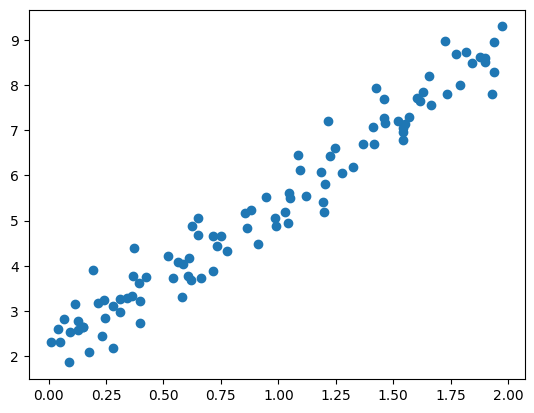

In [9]:
plt.scatter(X, y)

## Closed-form solution equivalent

In [63]:
model = SimpleLinearRegression()

model.train(X, y)

b0, b1 = model.params()

print("Parameters:")
print(f"\tb0 = {b0}")
print(f"\tb1 = {b1}")

print("Best fit line:")
print(f"\ty = {b0:.2f} + {b1:.2f}x")

Parameters:
	b0 = 2.1075480787733736
	b1 = 3.385056693219239
Best fit line:
	y = 2.11 + 3.39x


## Implementation of gradient descent

$$L = \sum(y-mx-b)^2$$
$$
\frac{\partial L}{\partial m} = -2\sum{x(y-mx-b)}
$$
$$
\frac{\partial L}{\partial b} = -2\sum{(y-mx-b)}
$$


In [79]:
def partial_m(X, Y, m, b):
    result = 0
    for x, y in zip(X, Y):
        result += x * (y - m*x - b)
    return (result * -2) / len(X)

def partial_b(X, Y, m, b):
    result = 0
    for x, y in zip(X, Y):
        result += y - m*x - b
    return (result * -2) / len(X)

In [ ]:
fixed_m = b1

init_b = 0
init_m = 0
lr = 0.001 # Added learning rate variable!

slope_b = partial_b(X, y, init_m, init_b)
step_b = slope_b * lr
next_b = init_b - step_b

slope_m = partial_m(X, y, init_m, init_b)
step_m = slope_m * lr
next_m = init_m - step_m

while abs(step_b) > 1e-10 or abs(step_m) > 1e-10:
    slope_b = partial_b(X, y, next_m, next_b)
    step_b = slope_b * lr
    next_b = next_b - step_b

    slope_m = partial_m(X, y, next_m, next_b)
    step_m = slope_m * lr
    next_m = next_m - step_m
    
print(next_b)
print(next_m)

2.1075480812482676
3.3850566910804902


In [69]:
n = len(X)
c_s = np.sum(y - fixed_m * X)
c_q = np.sum(np.square(y - fixed_m * X))

n, c_s, c_q

(100, np.float64(210.75480787733764), np.float64(464.34050453331156))

In [73]:
slb = partial_b(X, y, 0, 0)
print(slb)

print(partial_b(X, y, 0, 106))

-1058.145004712757
20141.854995287245


> My question is, how do we properly select for the best learning rate?

### Setting up the Environment
First, let's create a couple of helper functions. We need a function to dynamically calculate the Cost Function (Mean Squared Error) and a helper function to run multiple epochs/iterations of Gradient Descent so we don't have to keep writing the loops.

In [77]:
def compute_mse(X, Y, m, b):
    """Calculates the Mean Squared Error for the current weights"""
    error = 0
    for x, y in zip(X, Y):
        error += (y - (m * x + b)) ** 2
    return error / len(X)

def run_gradient_descent(X, Y, lr, epochs=50):
    """Runs full Gradient Descent for a given learning rate"""
    m, b = 0.0, 0.0 # initial values
    history = []
    
    for _ in range(epochs):
        cost = compute_mse(X, Y, m, b)
        history.append(cost)
        
        slope_m = partial_m(X, Y, m, b)
        slope_b = partial_b(X, Y, m, b)
        
        # We need a guard against exploding gradients (overflow)
        if np.isinf(cost) or np.isnan(cost) or cost > 1e15:
            return history, False
            
        m -= lr * slope_m # next value
        b -= lr * slope_b # next value
        
    return history, True

### Step 1: Logarithmic Grid Search
We will now test different orders of magnitude for our learning rate (`[1.0, 0.1, 0.01, 0.001, 0.0001]`). By plotting the **MSE over Time (Epochs)**, we can immediately visually identify if a learning rate diverges (explodes) or converges perfectly smoothly.

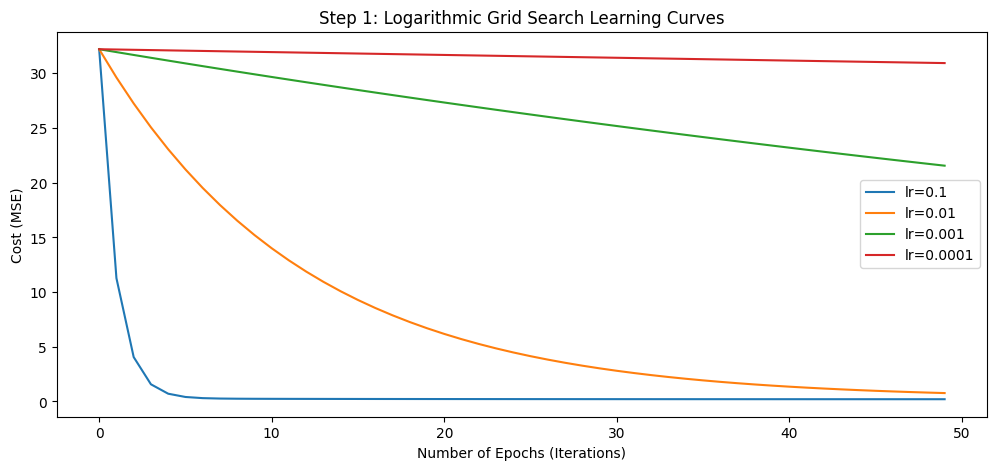

The best Logarithmic Scale found is: 0.1


In [78]:
learning_rates_to_test = [1.0, 0.1, 0.01, 0.001, 0.0001]
best_log_lr = None
min_log_cost = float('inf')

plt.figure(figsize=(12, 5))

# Loop over completely different scales of learning rates
for lr in learning_rates_to_test:
    hist, converged = run_gradient_descent(X, y, lr, epochs=50)
    
    # Validation: If the cost didn't blow up and actually decreased initially, plot it!
    if converged and len(hist) > 0 and (hist[-1] < hist[0] or np.isclose(hist[-1], hist[0])): 
        plt.plot(hist, label=f"lr={lr}")
        
        # Save the learning rate that produced the smallest final mean squared error
        if hist[-1] < min_log_cost:
            min_log_cost = hist[-1]
            best_log_lr = lr
    else:
        print(f"Warning: Learning rate {lr} was too high and completely DIVERGED!")

# Add labels so we can see what's happening
plt.title("Step 1: Logarithmic Grid Search Learning Curves")
plt.xlabel("Number of Epochs (Iterations)")
plt.ylabel("Cost (MSE)")
plt.legend()
plt.show()

print(f"The best Logarithmic Scale found is: {best_log_lr}")

### Step 2: Fine-Tuning
Now that we have discovered the *correct order of magnitude* in Step 1, we can manually zoom into that scale and test rates immediately around it `(0.5x, 1x, 2x, 5x)`. This lets us squeeze the absolutely perfect value before our learning curve begins bouncing around.

In [ ]:
if best_log_lr is not None:
    # Test values immediately surrounding the best logarithmic rate
    fine_tune_rates = [
        best_log_lr * 0.5, 
        best_log_lr, 
        best_log_lr * 2, 
        best_log_lr * 5
    ]
    
    best_fine_lr = None
    min_cost = float('inf')

    plt.figure(figsize=(12, 5))
    
    for lr in fine_tune_rates:
        hist, converged = run_gradient_descent(X, y, lr, epochs=100)
        
        if converged and len(hist) > 0 and not np.isnan(hist[-1]):
            plt.plot(hist, label=f"lr={lr}")
            if hist[-1] < min_cost:
                min_cost = hist[-1]
                best_fine_lr = lr

    plt.title("Step 2 & 3: Fine-Tuned Learning Curves")
    plt.xlabel("Number of Epochs (Iterations)")
    plt.ylabel("Cost (MSE)")
    plt.legend()
    plt.show()

    print(f"The best fine-tuned learning rate is: {best_fine_lr}")
else:
    print("Could not fine-tune because no valid logarithmic scale was found to converge.")